# Taller (Colab) — Regresión lineal múltiple: coeficientes, significancia y residuales

**Duración sugerida:** 50–60 min de trabajo + sustentación.

## Qué se evalúa hoy
1) **Interpretación de coeficientes** en regresión múltiple (cambio marginal, controlando por, unidades).
2) **Significancia por coeficiente** (t y p-valor, y coherencia con el IC).
3) **Lectura de residuales** (qué dicen y qué alertas sugieren).

---
## Definiciones mínimas (úsalas textual en la sustentación)

### A. Interpretación correcta de un coeficiente (plantilla obligatoria)
Para un predictor Xj:
> “Si Xj aumenta en **1 unidad**, la **nota esperada** cambia en **β̂j** puntos, **manteniendo constantes** los demás predictores del modelo.”

**Siempre debes mencionar:**
- signo (sube/baja),
- magnitud (cuánto),
- unidad (puntos de nota por unidad de Xj),
- y la frase “manteniendo constantes …”.

### B. Significancia (por coeficiente)
- Hipótesis: H0: βj = 0 vs H1: βj ≠ 0.
- t = β̂j / SE(β̂j).
- p-valor: evidencia contra H0 bajo los supuestos del modelo.

### C. Residuales (qué mirar)
- Residual = observado − predicho.
- Si hay patrón (curva/abanico) en residuales vs predichos → posible problema (no linealidad/heterocedasticidad).
- Outliers: residuales muy grandes en valor absoluto.


In [1]:
# 0) LIBRERÍAS (NO MODIFICAR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

np.random.seed(2026)
pd.set_option('display.precision', 4)
sns.set_style('whitegrid')

## Contexto y variables (común para todos)

**Unidad:** estudiante.

**Y:** `nota` (0 a 5)

**X:**
- `horas` = horas de estudio por semana
- `asistencia` = porcentaje de asistencia (0–100)
- `promedio` = promedio previo (0–5)


In [2]:
# 1) SIMULACIÓN BASE (NO MODIFICAR)
n = 300

promedio = np.clip(np.random.normal(3.5, 0.5, n), 0, 5)
asistencia = 70 + 8*(promedio-3.5) + np.random.normal(0, 10, n)
asistencia = np.clip(asistencia, 40, 100)
horas = 6 + 2.0*(promedio-3.5) + 0.05*(asistencia-70) + np.random.normal(0, 2.5, n)
horas = np.clip(horas, 0, 25)

eps = np.random.normal(0, 0.35, n)
nota = 0.6 + 0.05*horas + 0.012*asistencia + 0.55*promedio + eps
nota = np.clip(nota, 0, 5)

df = pd.DataFrame({'nota': nota, 'horas': horas, 'asistencia': asistencia, 'promedio': promedio})
df.head()

,nota,horas,asistencia,promedio
0,3.1953,2.2842,52.2924,3.2841
1,3.5160,4.6165,64.9618,2.8036
2,3.9114,2.5652,81.6452,3.6558
3,4.0231,8.3381,63.5462,3.4934
4,4.1592,12.3759,76.2580,4.2249


# Instrucciones del taller (USTEDES escriben el código)

## Entrega: 3 cosas
1) Tu notebook con el código.
2) Un párrafo final (8–10 líneas).
3) 2 gráficas guardadas en el notebook.

---
## Tareas (claras y numeradas)

### Parte 1 — Ajuste del modelo y coeficientes (interpretación)
1. Ajusta el modelo **M3**: `nota ~ horas + asistencia + promedio`.
2. Copia (o muestra) la tabla de coeficientes.
3. Interpreta **cada** coeficiente (horas, asistencia, promedio) con la **plantilla obligatoria**.
   - incluye signo, magnitud, unidad y “manteniendo constantes …”.
4. Interpreta el efecto de **+5 horas** usando el coeficiente de `horas`.

### Parte 2 — Significancia (por coeficiente)
5. Para cada predictor (horas, asistencia, promedio), responde:
   - H0 y H1.
   - p-valor: ¿rechazas H0 al 5%?
   - IC 95%: ¿incluye 0 o no?
   - Cierra con 1 frase: “significativo” NO es lo mismo que “importante”.

### Parte 3 — Residuales (lectura rápida y profesional)
6. Calcula residuales y valores ajustados (predichos).
7. Haz estas 2 gráficas:
   - (G1) Residuales vs Ajustados (scatter) + línea horizontal en 0.
   - (G2) Histograma de residuales (o QQ plot si sabes hacerlo).
8. Escribe 3 bullets:
   - ¿ves patrón (curva/abanico) o se ve “nube” alrededor de 0?
   - ¿hay outliers evidentes?
   - ¿qué supuesto podría fallar si ves abanico?

### Parte 4 — Modificación obligatoria (para forzar nueva interpretación)
Vamos a cambiar UNIDAD de una variable y a crear un nuevo modelo.
9. Crea `horas10 = horas / 10` y ajusta el modelo **M3b**: `nota ~ horas10 + asistencia + promedio`.
10. Compara β̂_horas (M3) vs β̂_horas10 (M3b) y escribe:
   - ¿por qué cambia el número?
   - ¿cómo cambia la interpretación en palabras?

---
## Párrafo final (8–10 líneas)
Incluye:
- interpretación correcta de los 3 coeficientes (resumida),
- 1 conclusión sobre significancia (sin exagerar causalidad),
- 1 conclusión sobre residuales,
- y 1 línea sobre el cambio de unidades (horas a decenas de horas).


## ***1.) Ajustes del model y coeficientes***

In [3]:
linreg_m3 = smf.ols(formula='nota ~ horas + asistencia + promedio', data=df).fit()
print(linreg_m3.summary())

                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     117.4
Date:                Mon, 09 Feb 2026   Prob (F-statistic):           4.25e-50
Time:                        21:53:17   Log-Likelihood:                -136.99
No. Observations:                 300   AIC:                             282.0
Df Residuals:                     296   BIC:                             296.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6487      0.191      3.404      0.0

### Interpretación:
 - Si las horas de estudio semanales aumentan en una unidad, la nota esperada aumenta $\approx$ 0.04 unidades, manteniendo constantes las demás variables
 - Si el porcentaje de asistencia promedio aumenta en una unidad, la nota esperada aumenta $\approx$ 0.01 unidad, manteniendo constantes las demás variables
 - Si el promedio previo aumenta en una unidad, la nota esperada aumenta $\approx$ 0.57 unidades, manteniendo constantes las demás variables
 - Si las horas de estudio por semana aumentan en 5 unidades, la nota esperada aumenta $\approx$ 0.206, manteniendo constantes las demás variables

## ***2.) Significancia (Por coeficientes)***

### Horas
$$H_0 : \beta_{horas} = 0\\ H_1 : \beta_{horas} \ne 0$$

In [4]:
print(f"""p-value: {linreg_m3.pvalues['horas']}
Intervalo de confianza del 95%: [{linreg_m3.conf_int().loc['horas'][0]:.2f}, {linreg_m3.conf_int().loc['horas'][1]:.2f}]""")

p-value: 5.996522499031629e-06
Intervalo de confianza del 95%: [0.02, 0.06]


Para la variable predictora de las horas de estudio semanales, se usa una prueba de hipótesis para ver si tiene un efecto lineal con la nota final. Dado que el p-valor ($5.99 \cdot 10^{-6}$) es menor a 0.05, se rechaza la hipótesis nula y se concluye que hay un efecto lineal. Esto es consistente con el intervalo de confianza del 95% ubicado entre 0.02 y 0.06.

### Asistencia
$$H_0 : \beta_{asistencia} = 0\\ H_1 : \beta_{asistencia} \ne 0$$

In [5]:
print(f"""p-value: {linreg_m3.pvalues['asistencia']}
Intervalo de confianza del 95%: [{linreg_m3.conf_int().loc['asistencia'][0]:.3f}, {linreg_m3.conf_int().loc['asistencia'][1]:.3f}]""")

p-value: 2.3269242819664565e-06
Intervalo de confianza del 95%: [0.006, 0.015]


Para la variable predictora de las asistencias semanales, se usa una prueba de hipótesis para ver si tiene un efecto lineal con la nota final. Dado que el p-valor ($2.32 \cdot 10^{-6}$) es menor a 0.05, se rechaza la hipótesis nula y se concluye que hay un efecto lineal. Esto es consistente con el intervalo de confianza del 95% ubicado entre 0.006 y 0.015.

### Promedio
$$H_0 : \beta_{promedio} = 0\\ H_1 : \beta_{promedio} \ne 0$$

In [6]:
print(f"""p-value: {linreg_m3.pvalues['promedio']}
Intervalo de confianza del 95%: [{linreg_m3.conf_int().loc['promedio'][0]:.2f}, {linreg_m3.conf_int().loc['promedio'][1]:.2f}]""")

p-value: 2.800671807402918e-25
Intervalo de confianza del 95%: [0.48, 0.67]


Para la variable predictora de las de las horas de estudio semanales, se usa una prueba de hipótesis para ver si tiene un efecto lineal con la nota final. Dado que el p-valor ($2.8 \cdot 10^{-25}$) es menor a 0.05, se rechaza la hipótesis nula y se concluye que hay un efecto lineal. Esto es consistente con el intervalo de confianza del 95% ubicado entre 0.48 y 0.67.

## ***3.) Residuales (Lectura rápida y profesional)***

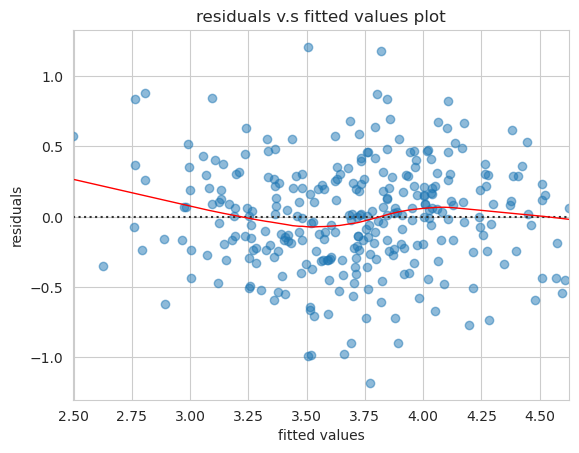

In [7]:
residuals = linreg_m3.resid
fitted_values = linreg_m3.fittedvalues

sns.residplot(
    data=df,
    x=fitted_values,
    y=residuals,
    lowess=True,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red', 'lw': 1}
)
plt.title("residuals v.s fitted values plot")
plt.xlabel("fitted values")
plt.ylabel("residuals")
plt.show()

### Interpretación
podemos observar en el gráfico de los residuos v.s valores predichos que todos se mantuvieron en una nube entre -1 y 1 con muy pocas excepciones; no contamos con presencia de *outliers* y los residuos no presentan una forma de "U". Esto nos indica que posiblemente se cumplen los supuestos de linealidad y homocedasticidad

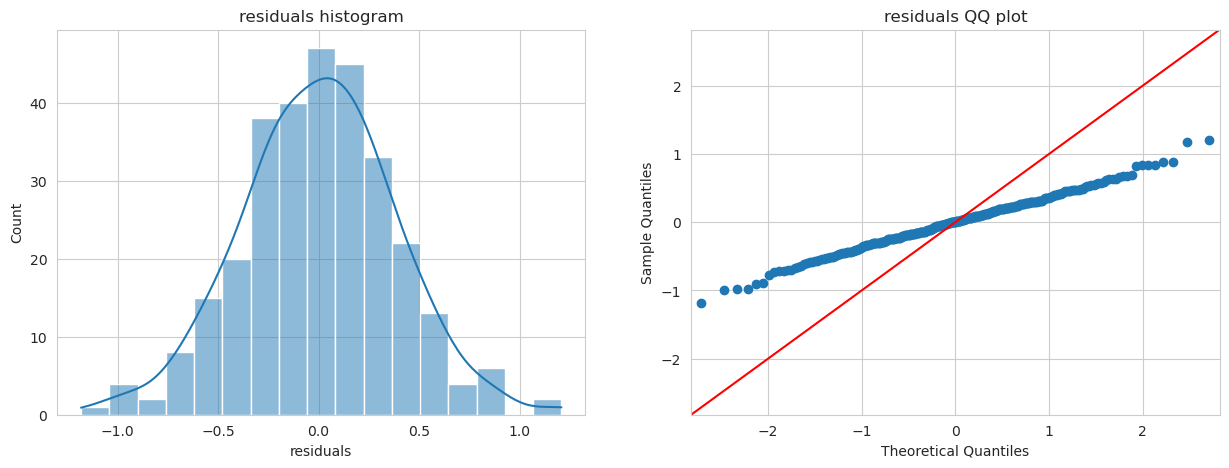

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    data=df,
    x=residuals,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("residuals histogram")
axes[0].set_xlabel("residuals")

sm.qqplot(
    residuals,
    line='45',
    ax=axes[1]
);
axes[1].set_title("residuals QQ plot")
plt.show()

### Interpretación

**1. Histograma de Residuos**
- Primero podemos observar que los residuos presentan una forma de campana, lo cual es un indicio de que los residuos siguen una distribución normal.
- El pico de la distribución se encuentra alrededor de 0, lo que sugiere que la media de los residuos es 0.

**2. QQ Plot**
- Podemos observar que la "pendiente" de los cuantiles es menor que los 45 de la recta teórica, lo que sugiere que los residuos no siguen una distribución normal.


## ***4.) Modificación obligatoria***

In [9]:
df['horas10'] = df['horas'] / 10

linreg_m3b = smf.ols(formula='nota ~ horas10 + asistencia + promedio', data=df).fit()
print(linreg_m3b.summary())

                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     117.4
Date:                Mon, 09 Feb 2026   Prob (F-statistic):           4.25e-50
Time:                        21:53:18   Log-Likelihood:                -136.99
No. Observations:                 300   AIC:                             282.0
Df Residuals:                     296   BIC:                             296.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6487      0.191      3.404      0.0

### Interpretación

El valor del coeficiente cambia porque se está cambiando la escala de la variable horas (al dividirla entre 10).

Entonces la interpretación cambia. Por cada unidad que aumente en 'horas10' (lo que significan 10 horas de estudio) el promedio de 'nota' aumenta en 0.41 unidades.

Como tal, los valores entre 'horas' y 'horas10', solo que están en diferentes escalas (horas * 10 = horas10), tienen el mismo efecto en la regresión, solo con con otra escala de variable.

# **5. Párrafo final**

Los coeficientes del modelo de regresión son muy fáciles de interpretar. Manteniendo constantes las demás variables:
- Por cada hora de estudio que aumente, la nota esperada aumenta en 0.04 unidades
- Por cada unidad que aumente la asistencia promedio, la nota esperada aumenta en 0.01 unidades
- Por cada unidad que aumente el promedio previo, la nota esperada aumenta en 0.57 unidades

Con las pruebas t de significancia podemos concluir que las tres variables predictoras son significativas para producir la nota esperada del estudiante. Gracias a las gráficas de los residuales v.s los valores predichos y el histograma podemos concluir que los residuos se distribuyen de manera normal y centrados en 0. Y con la nueva variable de "horas10" pudimos observar que lo único que cambió fue la escala, porque sigue teniendo el mismo efecto en el modelo